1. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ==========================================================
# 1. LOAD DATASET
# ==========================================================
nama_file_input = 'dataset_atribut_clustering.xlsx'
df = pd.read_excel(nama_file_input)

# ==========================================================
# 2. DEFINISI PARAMETER
# ==========================================================
fitur_cols = [
    'persen_pilpres',
    'persen_pileg_ri',
    'persen_pileg_prov',
    'persen_pileg_kokab',
    'persen_pilgub',
    'persen_pilwalbup',
    'persen_part_pilpres',
    'persen_part_pileg_ri',
    'persen_part_pileg_prov',
    'persen_part_pileg_kokab',
    'persen_part_pilgub',
    'persen_part_pilwalbup',
    'persen_baseline_pilwalbup'
]
# ==========================================================
# 3. CLEANING DATA
# ==========================================================
summary_und = df[fitur_cols].isnull().sum().reset_index()
summary_und.columns = ['Nama Parameter', 'Jumlah Data Kosong']
summary_und['Total Baris'] = len(df)
summary_und['Status'] = 'Data Lengkap'

# Menampilkan Ringkasan Data ke Layar
print("=== RINGKASAN DATA ===")
print("-" * 80)
print(summary_und.to_string(index=False))
print("-" * 80)

# ==========================================================
# 4. EXPORT LAPORAN AUDIT DATA KE EXCEL
# ==========================================================
#nama_file_t1 = "Kelengkapan_Data_Cleaning.xlsx"
#summary_und.to_excel(nama_file_t1, index=False)

#print(f"\n[INFO] Berkas Laporan Tahap 1 telah dihasilkan: {nama_file_t1}")


=== RINGKASAN DATA ===
--------------------------------------------------------------------------------
           Nama Parameter  Jumlah Data Kosong  Total Baris       Status
           persen_pilpres                   0          627 Data Lengkap
          persen_pileg_ri                   0          627 Data Lengkap
        persen_pileg_prov                   0          627 Data Lengkap
       persen_pileg_kokab                   0          627 Data Lengkap
            persen_pilgub                   0          627 Data Lengkap
         persen_pilwalbup                   0          627 Data Lengkap
      persen_part_pilpres                   0          627 Data Lengkap
     persen_part_pileg_ri                   0          627 Data Lengkap
   persen_part_pileg_prov                   0          627 Data Lengkap
  persen_part_pileg_kokab                   0          627 Data Lengkap
       persen_part_pilgub                   0          627 Data Lengkap
    persen_part_pilwalbup       

**TAHAP 2: DATA PREPARATION (STANDARISASI DATA)**

Tahap penyiapan data melalui proses standarisasi (Z-Score). Karena 12 parameter Utama dan 1 Parameter Pendukung penelitian memiliki rentang angka yang berbeda-beda, kita perlu menyamakan skalanya agar setiap variabel memiliki bobot yang adil dalam proses pengelompokan nanti. Hasil dari penyesuaian angka ini disimpan ke dalam file Excel sebagai data yang sudah siap untuk diolah secara statistik.

In [2]:
# ==========================================================
# 1. PROSES NORMALISASI (Z-SCORE)
# ==========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[fitur_cols])

# ==========================================================
# 2. PENYUSUNAN KEMBALI DATAFRAME (DF_FINAL)
# ==========================================================
df_final = pd.DataFrame(X_scaled, columns=fitur_cols)
df_final.insert(0, 'nama_kecamatan', df['nama_kecamatan'].values)
df_final.insert(0, 'kab_kota', df['kab_kota'].values)
df_final.insert(0, 'id_kec', df['id_kec'].values)

# ==========================================================
# 3. PENGECEKAN HASIL (SAMPEL 10 BARIS)
# ==========================================================
sampel_10 = df_final.sample(n=10, random_state=42)

print("=== TAMPILAN SAMPEL DATA HASIL STANDARISASI  ===")
print("-" * 130)
print(sampel_10.to_string(index=False))
print("-" * 130)

# ==========================================================
# 4. EXPORT DATA HASIL PREPARASI KE EXCEL
# ==========================================================
nama_file_t2 = "Hasil_Normalisasi_ZScore.xlsx"
df_final.to_excel(nama_file_t2, index=False)

print(f"\n[INFO] Berkas Laporan Tahap 2 telah dihasilkan: {nama_file_t2}")


KeyError: 'nama_kecamatan'

**TAHAP 3: MODELING (PENCARIAN JUMLAH KLASTER TERBAIK)**

Tahap pembentukan model clustering untuk menentukan jumlah kelompok wilayah (K) yang paling tepat. Kita menggunakan tiga metode pengujian statistik secara bersamaan (Elbow, Silhouette, dan Davies-Bouldin) agar hasil pembagian zona wilayah didasari oleh bukti matematis yang kuat. Dokumentasi angka pengujian ini disimpan dalam format Excel sebagai landasan ilmiah dalam menentukan jumlah klaster akhir.

Sedang memproses perhitungan validasi otomatis...
---------------------------------------------------------------------------
K= 2 | SSE:5,878 | Silh:0.247 | DBI:1.499
K= 3 | SSE:5,026 | Silh:0.194 | DBI:1.689
K= 4 | SSE:4,487 | Silh:0.212 | DBI:1.422
K= 5 | SSE:3,964 | Silh:0.211 | DBI:1.380
K= 6 | SSE:3,664 | Silh:0.203 | DBI:1.430
K= 7 | SSE:3,425 | Silh:0.203 | DBI:1.399
K= 8 | SSE:3,236 | Silh:0.188 | DBI:1.533
K= 9 | SSE:3,048 | Silh:0.201 | DBI:1.416
K=10 | SSE:2,891 | Silh:0.198 | DBI:1.380
---------------------------------------------------------------------------


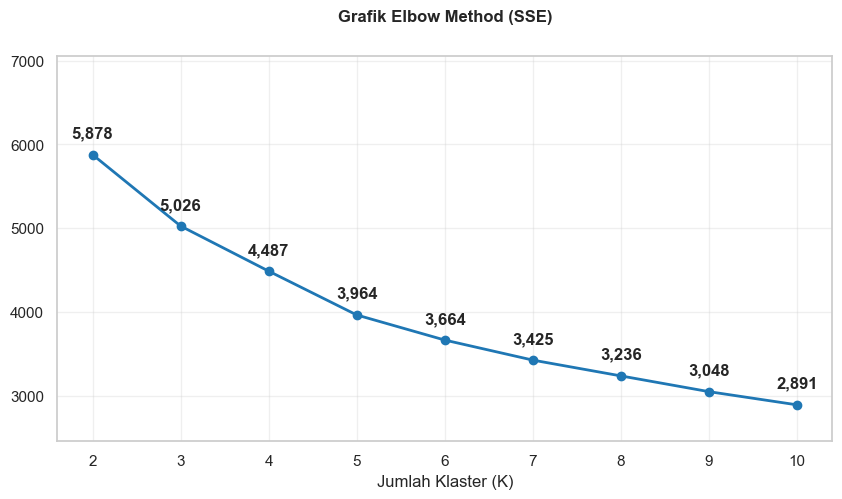

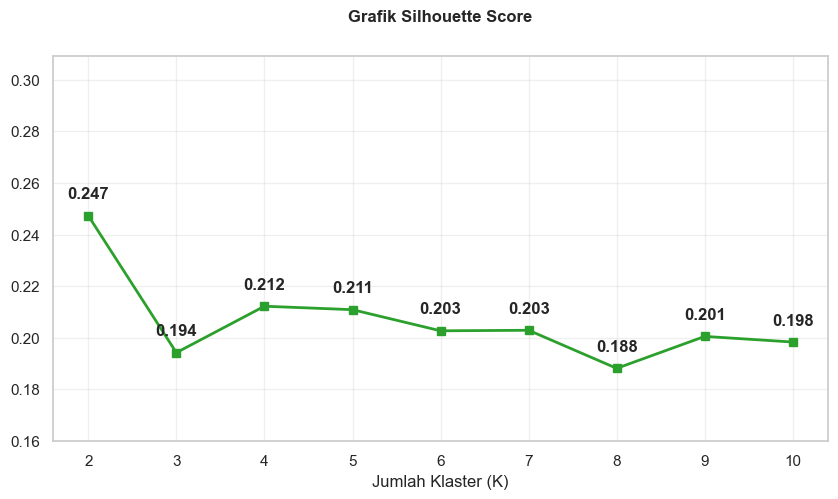

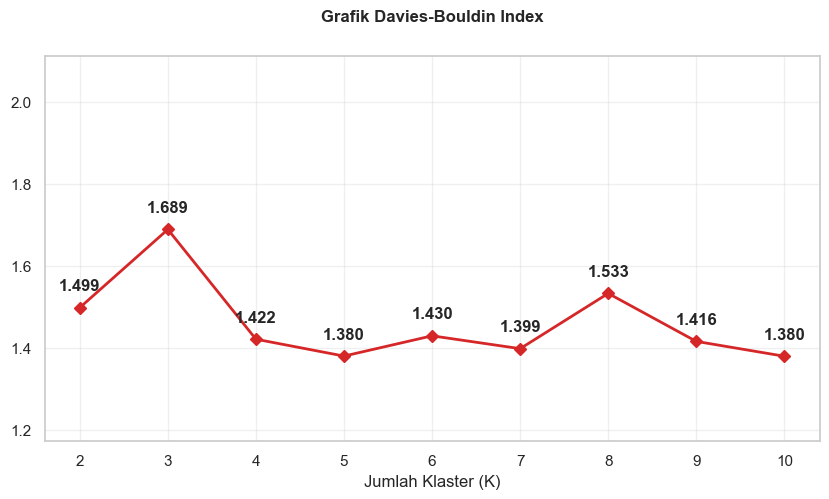

In [ ]:
# ==========================================================
# 1. PERHITUNGAN VALIDASI K-OPTIMAL (RANGE 2-10)
# ==========================================================
k_range = range(2, 11)
list_sse, list_silhouette, list_dbi = [], [], []

print("Sedang memproses perhitungan validasi otomatis...")
print("-" * 75)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    list_sse.append(kmeans.inertia_)
    list_silhouette.append(silhouette_score(X_scaled, labels))
    list_dbi.append(davies_bouldin_score(X_scaled, labels))
    
    print(f"K={k:2d} | SSE:{list_sse[-1]:,.0f} | Silh:{list_silhouette[-1]:.3f} | DBI:{list_dbi[-1]:.3f}")

print("-" * 75)

# ==========================================================
# 2. VISUALISASI GRAFIK TERPISAH (GAYA JUDUL MULAI KATA GRAFIK)
# ==========================================================

# --- GRAFIK 1: ELBOW METHOD ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_sse, marker='o', color='#1f77b4', linewidth=2)
plt.ylim(min(list_sse)*0.85, max(list_sse)*1.20) 
for i, val in enumerate(list_sse):
    plt.annotate(f'{val:,.0f}', (list(k_range)[i], list_sse[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Elbow Method (SSE)', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n") 

# --- GRAFIK 2: SILHOUETTE SCORE ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_silhouette, marker='s', color='#2ca02c', linewidth=2)
plt.ylim(min(list_silhouette)*0.85, max(list_silhouette)*1.25)
for i, val in enumerate(list_silhouette):
    plt.annotate(f'{val:.3f}', (list(k_range)[i], list_silhouette[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Silhouette Score', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n") 

# --- GRAFIK 3: DAVIES-BOULDIN INDEX ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_dbi, marker='D', color='#d62728', linewidth=2)
plt.ylim(min(list_dbi)*0.85, max(list_dbi)*1.25)
for i, val in enumerate(list_dbi):
    plt.annotate(f'{val:.3f}', (list(k_range)[i], list_dbi[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Davies-Bouldin Index', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# 3. EXPORT HASIL PENGUJIAN KE EXCEL
# ==========================================================
#df_val_excel = pd.DataFrame({
    #'K': list(k_range), 'SSE': list_sse, 'Silhouette': list_silhouette, 'DBI': list_dbi
#})
#df_val_excel.to_excel("Hasil_Validasi_Modeling_K.xlsx", index=False)
#print(f"\n[INFO] Laporan Tahap 3 telah dicetak: Hasil_Validasi_Modeling_K.xlsx")


**TAHAP 4: MODEL EXECUTION (FINAL RUN & PCA)**

Tahap implementasi model clustering menggunakan jumlah kelompok yang telah ditentukan (K=5). Pada tahap ini, kita menghitung sebaran kecamatan di setiap zona wilayah dan memvisualisasikannya melalui teknik PCA (Principal Component Analysis). Proses PCA dilakukan untuk mereduksi 12 dimensi parameter menjadi 2 dimensi visual agar pola persebaran antar klaster dapat diamati secara spasial. Laporan distribusi kecamatan diekspor ke format Excel sebagai basis data zonasi.

=== REKAPITULASI DISTRIBUSI SEBARAN KLASTER (TAHAP 4) ===
-----------------------------------------------------------------
Label Klaster  Jumlah Kecamatan  Persentase (%)
            0                27            4.31
            1               157           25.04
            2               149           23.76
            3               201           32.06
            4                93           14.83
        Total               627          100.00
-----------------------------------------------------------------


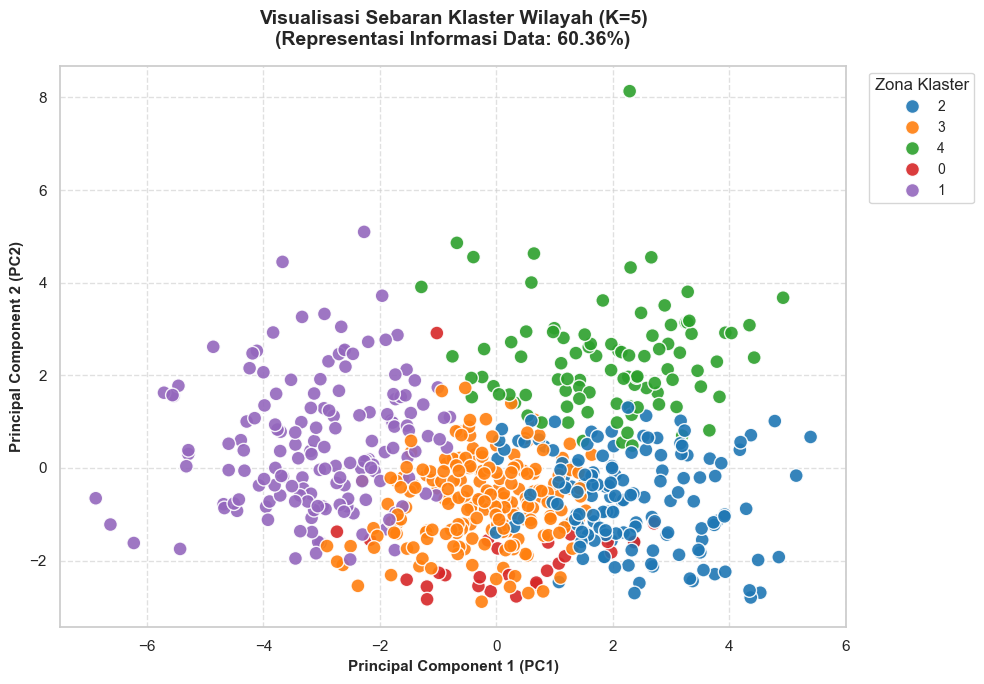


[INFO] Berkas Laporan Tahap 4 (Distribusi Wilayah) telah dihasilkan: Hasil_Distribusi_Zonasi_K5.xlsx


In [ ]:
# ==========================================================
# 1. PENETAPAN K FINAL & EKSEKUSI K-MEANS
# ==========================================================
# Menjalankan algoritma K-Means dengan K=5 (Berdasarkan hasil validasi Tahap 3)
k_final = 5
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# ==========================================================
# 2. EVALUASI DISTRIBUSI WILAYAH (LOGIKA TOTAL)
# ==========================================================
dist = df['Cluster_Label'].value_counts().sort_index().reset_index()
dist.columns = ['Label Klaster', 'Jumlah Kecamatan']
dist['Persentase (%)'] = (dist['Jumlah Kecamatan'] / len(df) * 100).round(2)

baris_total = pd.DataFrame({
    'Label Klaster': ['Total'],
    'Jumlah Kecamatan': [dist['Jumlah Kecamatan'].sum()],
    'Persentase (%)': [100.0]
})
tabel_distribusi_final = pd.concat([dist, baris_total], ignore_index=True)

print("=== REKAPITULASI DISTRIBUSI SEBARAN KLASTER (TAHAP 4) ===")
print("-" * 65)
print(tabel_distribusi_final.to_string(index=False))
print("-" * 65)

# ==========================================================
# 3. VISUALISASI SEBARAN KLASTER (MENGGUNAKAN PCA)
# ==========================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
acc_pca = np.sum(pca.explained_variance_ratio_) * 100 

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster_Label'].astype(str)

plt.figure(figsize=(10, 7)) 
sns.set_theme(style="whitegrid", palette="muted")

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, 
                palette='tab10', s=100, alpha=0.9, edgecolor='white', linewidth=1)

plt.title(f'Visualisasi Sebaran Klaster Wilayah (K={k_final})\n(Representasi Informasi Data: {acc_pca:.2f}%)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontweight='bold', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontweight='bold', fontsize=11)
plt.legend(title='Zona Klaster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================================
# 4. EXPORT HASIL DISTRIBUSI K KE EXCEL
# ==========================================================
nama_file_t4 = f"Hasil_Distribusi_Zonasi_K{k_final}.xlsx"
tabel_distribusi_final.to_excel(nama_file_t4, index=False)

print(f"\n[INFO] Berkas Laporan Tahap 4 (Distribusi Wilayah) telah dihasilkan: {nama_file_t4}")


**TAHAP 5: EVALUATION (PROFILING & KNOWLEDGE DISCOVERY)**

Tahap akhir penelitian untuk menemukan pengetahuan melalui interpretasi setiap kelompok wilayah (Klaster). Di sini kita membedah nilai rata-rata (Centroid) dari 12 parameter pada setiap klaster guna mengidentifikasi karakteristik unik di tingkat kecamatan secara objektif. Melalui visualisasi Heatmap, pola perbedaan perilaku pemilih dan tingkat partisipasi antar zona wilayah akan terlihat jelas sebagai dasar pengambilan kesimpulan riset. Seluruh data hasil pengelompokan akhir diekspor ke format Excel sebagai luaran (output) utama penelitian.

=== TABEL EVALUASI PROFIL KARAKTERISTIK (CENTROID TAHAP 5) ===
-----------------------------------------------------------------------------------------------------------------------------------------------------------
 Label_Klaster  Jumlah_Kecamatan  %_v_pres  %_v_pileg_ri  %_v_pileg_prov  %_v_pileg_kokab  %_v_pilkada_gub  %_v_pilkada_kokab  %_part_pilpres  %_part_pileg_ri  %_part_pileg_prov  %_part_pileg_kab  %_part_pilkada_gub  %_part_pilkada_kokab  n_paslon_pilkada_kokab
             0                27     49.69         14.33           11.85            11.50            56.90              89.90           80.69            80.51              81.00             80.11               71.05                 70.94                  100.00
             1               157     59.92         16.72           16.73            15.85            59.41              35.18           75.18            75.07              74.96             74.95               60.20                 59.71                   3

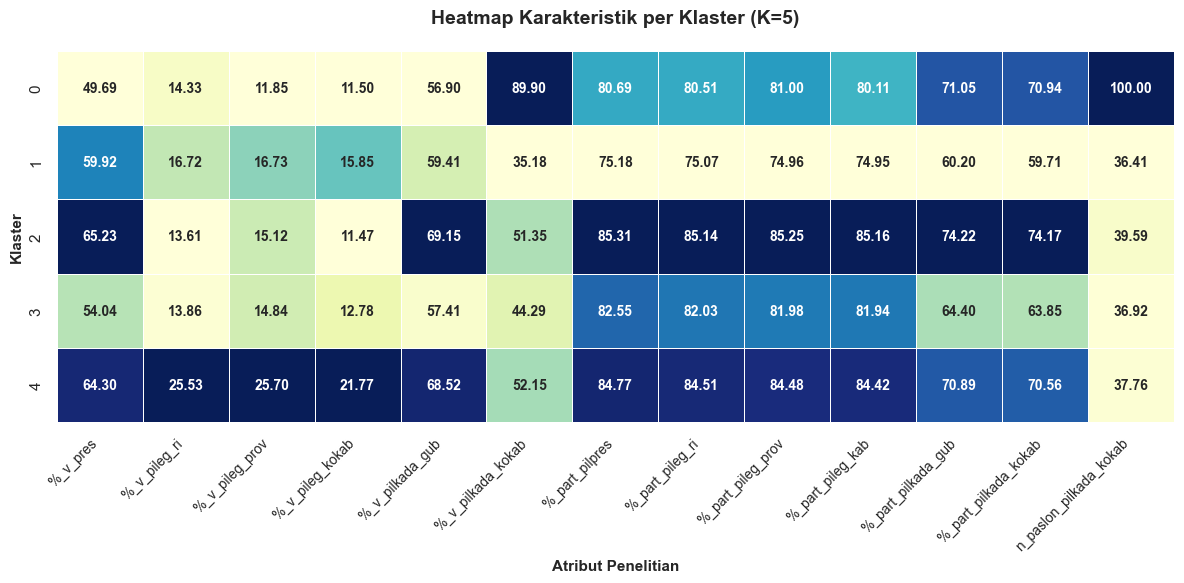


[INFO] Berkas Laporan Akhir Berhasil Dihasilkan:
1. Evaluasi_Profiling_Centroid_K5.xlsx
2. Master_Data_Berlabel_Final_K5.xlsx

=== SELURUH TAHAPAN CRISP-DM TELAH SELESAI ===


In [ ]:
# ==========================================================
# 1. ANALISIS KARAKTERISTIK (PROFILING CENTROID)
# ==========================================================
tabel_profiling = df.groupby('Cluster_Label')[fitur_cols].mean().round(2)
tabel_profiling.insert(0, 'Jumlah_Kecamatan', df['Cluster_Label'].value_counts().sort_index())

tabel_profiling = tabel_profiling.reset_index()
tabel_profiling.rename(columns={'Cluster_Label': 'Label_Klaster'}, inplace=True)

print("=== TABEL EVALUASI PROFIL KARAKTERISTIK (CENTROID TAHAP 5) ===")
print("-" * 155)
print(tabel_profiling.to_string(index=False))
print("-" * 155)

# ==========================================================
# 2. VISUALISASI HEATMAP (UKURAN STANDAR / NORMAL)
# ==========================================================
prof_norm = (tabel_profiling[fitur_cols] - tabel_profiling[fitur_cols].min()) / \
            (tabel_profiling[fitur_cols].max() - tabel_profiling[fitur_cols].min())

plt.figure(figsize=(12, 6)) 
sns.heatmap(prof_norm, annot=tabel_profiling[fitur_cols], fmt=".2f", 
            cmap="YlGnBu", linewidths=.5, cbar=False, annot_kws={"size": 10, "weight": "bold"})

plt.title(f'Heatmap Karakteristik per Klaster (K={k_final})', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Atribut Penelitian', fontweight='bold', fontsize=11)
plt.ylabel('Klaster', fontweight='bold', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================================
# 3. FINAL EXPORT (LAPORAN AKHIR)
# ==========================================================
nama_file_profil = f"Evaluasi_Profiling_Centroid_K{k_final}.xlsx"
nama_file_master = f"Master_Data_Berlabel_Final_K{k_final}.xlsx"

tabel_profiling.to_excel(nama_file_profil, index=False)
df.to_excel(nama_file_master, index=False)

print(f"\n[INFO] Berkas Laporan Akhir Berhasil Dihasilkan:")
print(f"1. {nama_file_profil}")
print(f"2. {nama_file_master}")
print("\n" + "="*50)
print("=== SELURUH TAHAPAN CRISP-DM TELAH SELESAI ===")
print("="*50)


**ANALISIS KECAMATAN DENGAN KINERJA EKSTRIM**

Berdasarkan hasil visualisasi sebaran data (PCA) di Tahap 4, teridentifikasi satu wilayah kecamatan yang memiliki posisi sangat berjauhan (outlier) di atas rata-rata sebaran wilayah lainnya. Tahap analisis khusus ini bertujuan untuk membedah identitas dan karakteristik 12 parameter pada kecamatan tersebut guna memahami faktor pendorong utama (Key Drivers) di balik dominansi perolehan suara serta tingkat partisipasi yang sangat tinggi di wilayah tersebut. Temuan ini penting dikaji sebagai model acuan strategi pemenangan di wilayah lainnya.

=== ANALISIS KECAMATAN SEBAGAI TITIK BATAS (BOUNDARY INDICATORS) ===
--------------------------------------------------------------------------------------------------------------

>>> Titik Batas Atas (PC2 Max)
 id_kec kab_kota nama_kecamatan  Cluster_Label
 320105    BOGOR BABAKAN MADANG              4
             Parameter  Nilai Asli (%)
              %_v_pres           69.78
          %_v_pileg_ri           44.54
        %_v_pileg_prov           46.23
       %_v_pileg_kokab           46.23
       %_v_pilkada_gub           68.13
     %_v_pilkada_kokab           83.03
        %_part_pilpres           88.45
       %_part_pileg_ri           86.33
     %_part_pileg_prov           86.34
      %_part_pileg_kab           86.34
    %_part_pilkada_gub           58.90
  %_part_pilkada_kokab           58.89
n_paslon_pilkada_kokab           50.00
---------------------------------------------------------------------------

>>> Titik Batas Bawah (PC2 Min)
 id_kec  kab_kota nama_kecamatan  Clust

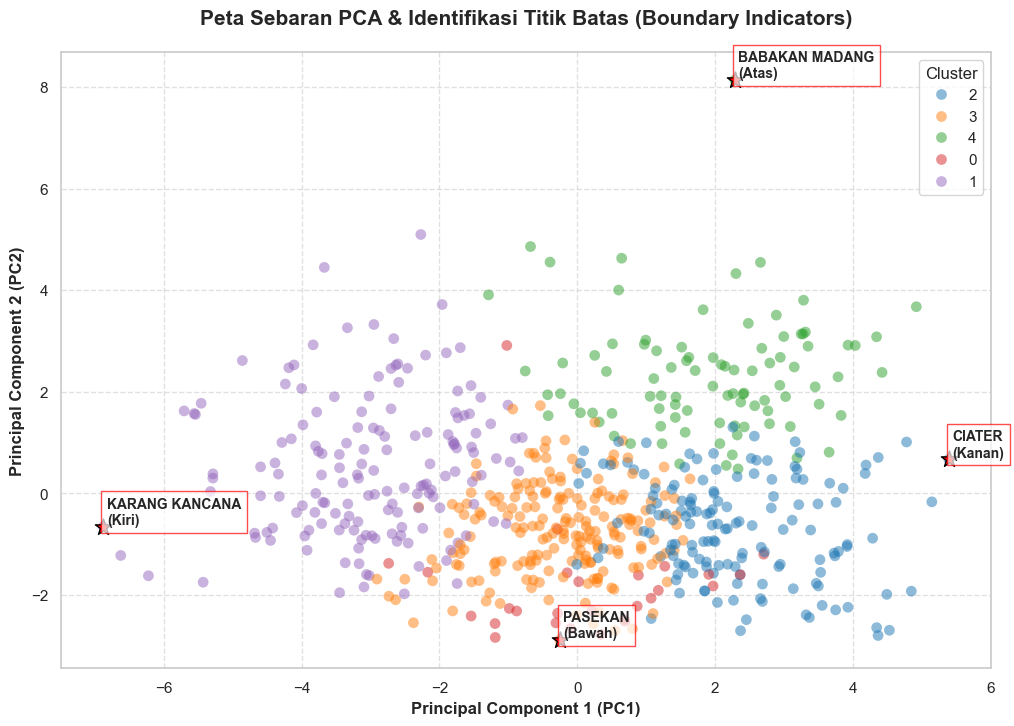

In [ ]:
# ==========================================================
# 1. IDENTIFIKASI TITIK BATAS (BOUNDARY INDICATORS - PCA)
# ==========================================================
outliers = {
    "Titik Batas Atas (PC2 Max)": df_pca['PC2'].idxmax(),
    "Titik Batas Bawah (PC2 Min)": df_pca['PC2'].idxmin(),
    "Titik Batas Kanan (PC1 Max)": df_pca['PC1'].idxmax(),
    "Titik Batas Kiri (PC1 Min)": df_pca['PC1'].idxmin()
}

print("=== ANALISIS KECAMATAN SEBAGAI TITIK BATAS (BOUNDARY INDICATORS) ===")
print("-" * 110)

for label, idx in outliers.items():
    info_kec = df.iloc[[idx]]
    print(f"\n>>> {label}")
    print(info_kec[['id_kec', 'kab_kota', 'nama_kecamatan', 'Cluster_Label']].to_string(index=False))
    
    # Detail fitur (Transpose vertikal)
    detail_param = info_kec[fitur_cols].T.reset_index()
    detail_param.columns = ['Parameter', 'Nilai Asli (%)']
    print(detail_param.to_string(index=False))
    print("-" * 75)

# ==========================================================
# 2. VISUALISASI POSISI TITIK BATAS (PCA)
# ==========================================================
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Plot semua titik
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, 
                palette='tab10', s=60, alpha=0.5, edgecolor='none')

# Highlight dan Label Outlier
for label, idx in outliers.items():
    row = df_pca.iloc[idx]
    nama_kec = df.iloc[idx]['nama_kecamatan']
    
    # Tambah marker khusus
    plt.scatter(row['PC1'], row['PC2'], color='red', s=150, marker='*', edgecolors='black', label=f"Titik Batas: {nama_kec}")
    
    # Tambah teks label
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, f"{nama_kec}\n({label.split(' ')[2]})", 
             fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))

plt.title('Peta Sebaran PCA & Identifikasi Titik Batas (Boundary Indicators)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Principal Component 1 (PC1)', fontweight='bold')
plt.ylabel('Principal Component 2 (PC2)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. EXPORT HASIL ANALISIS KHUSUS
df_outliers_all = df.iloc[list(outliers.values())].copy()
df_outliers_all['Kategori_Batas'] = list(outliers.keys())
df_outliers_all.to_excel("Analisis_Kecamatan_Titik_Batas_Lengkap.xlsx", index=False)
